<a href="https://colab.research.google.com/github/zeegy99/Quant_Backtesting_Models/blob/main/Pairwise_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pairs Trading — Statistical Arbitrage (KO / PEP)

This notebook implements a mean-reversion pairs trading strategy on two sets of pairs: [Coca-Cola (KO) and PepsiCo (PEP)] which has been a known pair for quite some time.

**Methodology:**
1. **EDA** — Visualize and compute summary statistics for both stocks
2. **Correlation** — Use Pearson's r to quantify co-movement
3. **Linear Regression (SGD)** — Model PEP as a function of KO to estimate the 'true' equilibrium relationship
4. **ADF Test** — Verify that the spread is stationary (mean-reverting), which is a prerequisite for pairs trading
5. **Signal Generation** — Identify divergences beyond ±2σ
6. **Backtest** — Simulate a simple long/short strategy and evaluate performance




# Results

KO and Pep did not pass the ADF test, meaning the spread was not mean-reverting. In theory we are unable to implement pairs trading. We tried anyways and got very poor results (as expected)

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from datetime import datetime, timedelta

## 1. EDA

In [2]:
TICKERS = ['KO', 'PEP']
START = '2015-01-01'
END   = '2025-01-01'

data = yf.download(TICKERS, start=START, end=END, auto_adjust=False, actions=False)['Close']
data.columns = ['KO', 'PEP']

print(f"Shape: {data.shape}")
print(data.head())

[*********************100%***********************]  2 of 2 completed

Shape: (2516, 2)
                   KO        PEP
Date                            
2015-01-02  42.139999  94.440002
2015-01-05  42.139999  93.730003
2015-01-06  42.459999  93.019997
2015-01-07  42.990002  95.739998
2015-01-08  43.509998  97.480003


In [5]:

print(data['KO'].describe())
print(data['PEP'].describe())
returns = data.pct_change().dropna()

print("Annualized Volatility\n")
print(f"  KO : {returns['KO'].std() * np.sqrt(252):.4f}")
print(f"  PEP: {returns['PEP'].std() * np.sqrt(252):.4f}")

print(f"Return Correlation: {returns['KO'].corr(returns['PEP']):.4f}")


count    2516.000000
mean       51.488378
std         8.217208
min        37.560001
25%        44.437499
50%        49.684999
75%        59.320001
max        73.010002
Name: KO, dtype: float64
count    2516.000000
mean      135.662715
std        29.280927
min        89.639999
25%       109.172501
50%       133.345001
75%       166.092503
max       196.119995
Name: PEP, dtype: float64
Annualized Volatility

  KO : 0.1785
  PEP: 0.1869
Return Correlation: 0.7324


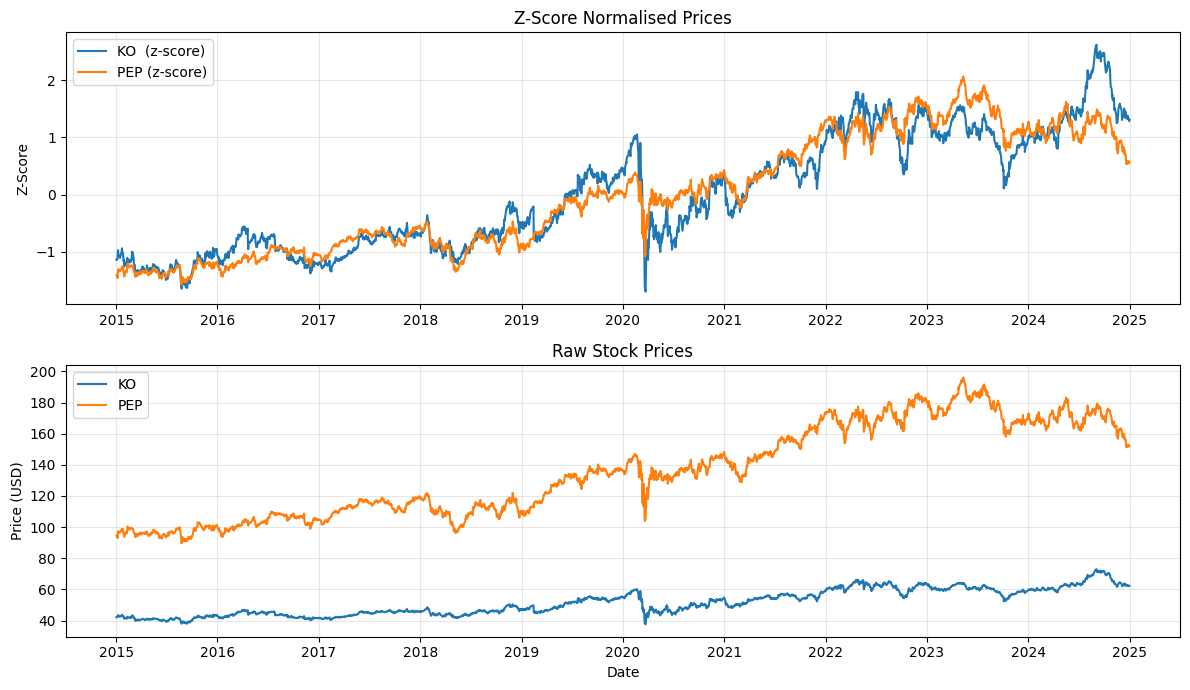

In [6]:
#z-score normalisation & plot
ko_mean, ko_std   = data['KO'].mean(), data['KO'].std()
pep_mean, pep_std = data['PEP'].mean(), data['PEP'].std()

ko_norm  = (data['KO']  - ko_mean)  / ko_std
pep_norm = (data['PEP'] - pep_mean) / pep_std

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(ko_norm,  label='KO  (z-score)')
axes[0].plot(pep_norm, label='PEP (z-score)')
axes[0].set_title('Z-Score Normalised Prices')
axes[0].set_ylabel('Z-Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(data['KO'],  label='KO')
axes[1].plot(data['PEP'], label='PEP')
axes[1].set_title('Raw Stock Prices')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Pearson Correlation Test

We test whether KO and PEP daily returns are significantly correlated.  
H₀: ρ = 0 (no correlation).  
A very small p-value lets us reject H₀ and confirms co-movement.

In [8]:
pearson_result = stats.pearsonr(returns['KO'], returns['PEP'])
print(f"Pearson r  : {pearson_result[0]:.4f}")
print(f"p-value    : {pearson_result[1]:.2e}")


Pearson r  : 0.7324
p-value    : 0.00e+00


**Manual Linear Regression via SGD**

This is to find the best slope parameters to model best-fit parameters.
For sanity, we will check with the libraries

In [10]:
df = data.copy()
x_vals = df['KO'].values
y_vals = df['PEP'].values

epochs = 10_000
alpha     = 0.0001
slope, intercept = 0, 0
n = len(x_vals)

for _ in range(epochs):
    y_pred   = slope * x_vals + intercept
    d_slope  = (-2 / n) * np.dot(x_vals, (y_vals - y_pred))
    d_int    = (-2 / n) * np.sum(y_vals - y_pred)
    slope     -= alpha * d_slope
    intercept -= alpha * d_int

print(f"slope: {slope:.4f}, intercept: {intercept:.4f}")



df['Predicted_PEP'] = slope * df['KO'] + intercept

slope: 2.6860, intercept: -1.7553


In [11]:
#OLS
ols_model  = OLS(df['PEP'], df['KO']).fit()
ols_slope  = ols_model.params[0]
ols_slope

/tmp/ipykernel_6014/1215200519.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ols_slope  = ols_model.params[0]


np.float64(2.652776769493939)

Running manual linear regression to find how to model Pepsi in terms of coke

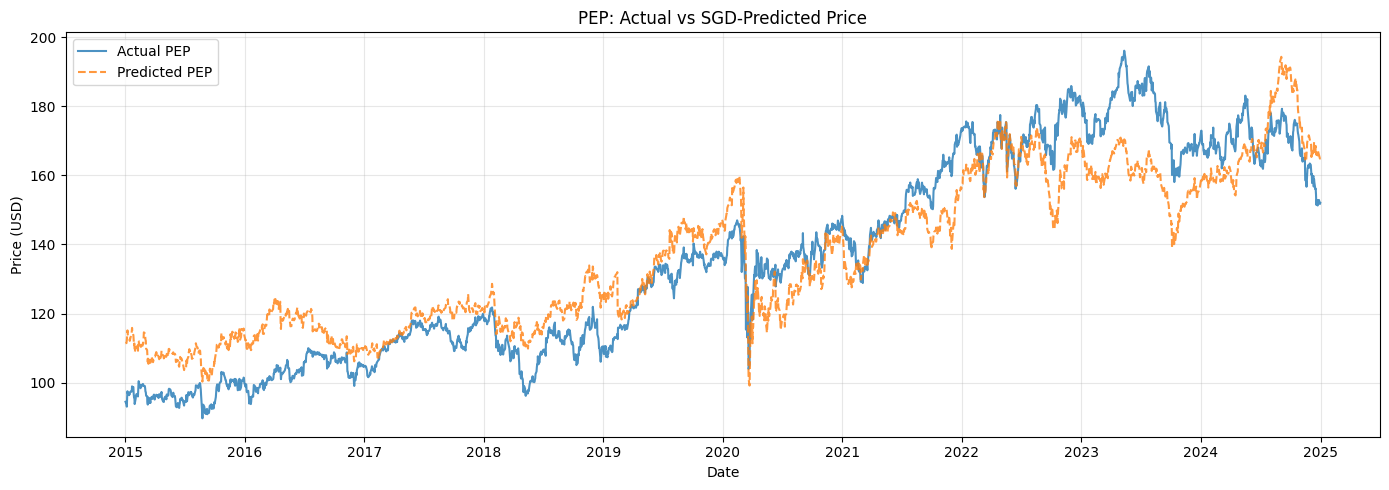

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['PEP'],           label='Actual PEP',    alpha=0.8)
plt.plot(df.index, df['Predicted_PEP'], label='Predicted PEP', linestyle='--', alpha=0.8)
plt.title('PEP: Actual vs SGD-Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Spread Construction & ADF Stationarity Test

The **spread** is the normalised difference between PEP's actual price and its model-predicted value.  
For pairs trading to work, this spread must be **stationary** (mean-reverting).

**Augmented Dickey-Fuller (ADF) Test**  
H₀: the series has a unit root (non-stationary).  
A p-value < 0.05 lets us reject H₀ → the spread is stationary → pairs trading is viable.

In [15]:
spread = (df['PEP'] - df['Predicted_PEP']) / df['KO']
df['Spread'] = spread


adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, _ = adfuller(spread.dropna())

print("ADF Test on Spread")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_pvalue:.4f}")
print(f"  Critical values:")
for key, val in adf_crit.items():
    print(f"    {key}: {val:.4f}")

if adf_pvalue < 0.05:
    print("Can run pairs trade.")
else:
    print("Cannot run pairs trade")

ADF Test on Spread
  ADF Statistic : -2.4844
  p-value       : 0.1193
  Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
Cannot run pairs trade


In [19]:
spread2 = (df['PEP'] - df['Predicted_PEP'])
df['Spread'] = spread2


adf_stat, adf_pvalue, adf_lags, adf_nobs, adf_crit, _ = adfuller(spread2.dropna())

print("ADF Test on Spread")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_pvalue:.4f}")
print(f"  Critical values:")
for key, val in adf_crit.items():
    print(f"    {key}: {val:.4f}")

if adf_pvalue < 0.05:
    print("Can run pairs trade.")
else:
    print("Cannot run pairs trade")

ADF Test on Spread
  ADF Statistic : -2.3672
  p-value       : 0.1512
  Critical values:
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
Cannot run pairs trade


Surprisingly, KO and Pep are not cointegrated. I suspect the reason why is that KO is not just a coke company anymore. Also maybe Covid has something to do with this?

In [28]:
from statsmodels.tsa.stattools import coint
import yfinance as yf

periods = [
    ('2000-01-01', '2002-01-01'),
    ('2010-01-01', '2012-01-01'),
    ('2015-01-01', '2018-01-01'),
    ('2018-01-01', '2021-01-01'),
    ('2021-01-01', '2025-01-01'),
    ('2015-01-01', '2020-01-01'),
    ('2019-01-01', '2023-01-01'),
]

for start, end in periods:
    ko  = yf.download('KO',  start=start, end=end, auto_adjust=True)['Close']
    pep = yf.download('PEP', start=start, end=end, auto_adjust=True)['Close']
    _, p, _ = coint(ko, pep)
    status = '1' if p < 0.05 else '0'
    print(f"{start} → {end}:  p = {p:.4f}  {status}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

2000-01-01 → 2002-01-01:  p = 0.4502  0
2010-01-01 → 2012-01-01:  p = 0.8713  0



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

2015-01-01 → 2018-01-01:  p = 0.3794  0



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

2021-01-01 → 2025-01-01:  p = 0.8472  0



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

2015-01-01 → 2020-01-01:  p = 0.0889  0


2019-01-01 → 2023-01-01:  p = 0.0934  0


Since KO and Pep fail the ADF Test, there is a unit root and these two have changing mean/variance, making them correlated (Pearson) but not cointegrated.

We will continue and see what it would look like if we pair traded, but I suspect the results will be poor.

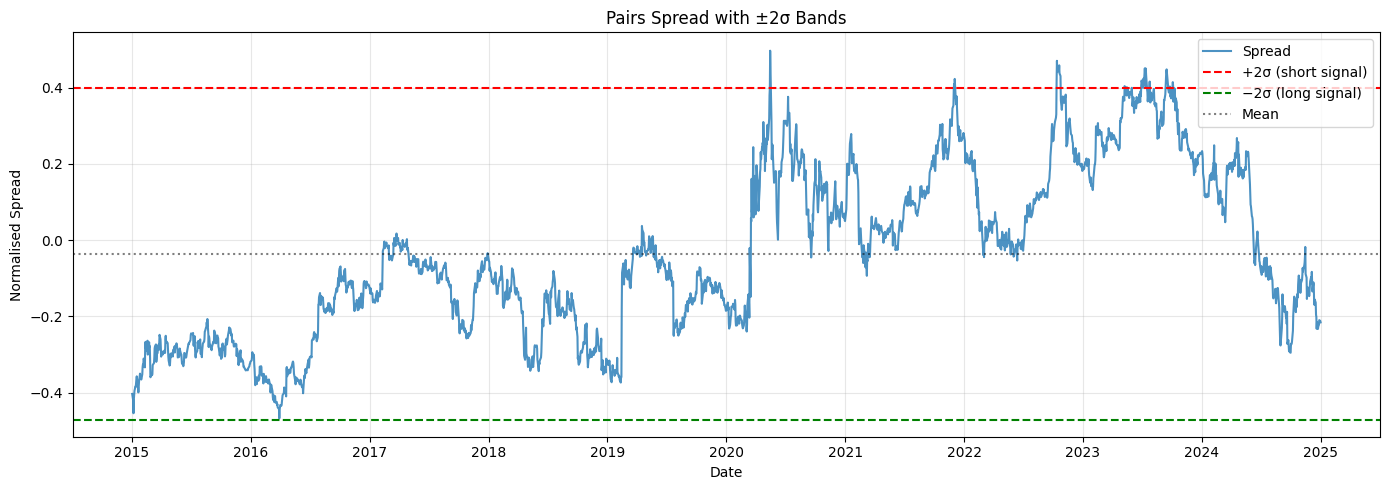

In [16]:
spread_mean = spread.mean()
spread_std  = spread.std()

upper_band = spread_mean + 2 * spread_std
lower_band = spread_mean - 2 * spread_std

plt.figure(figsize=(14, 5))
plt.plot(df.index, spread, label='Spread', alpha=0.8)
plt.axhline(upper_band, color='red',   linestyle='--', label='+2σ (short signal)')
plt.axhline(lower_band, color='green', linestyle='--', label='−2σ (long signal)')
plt.axhline(spread_mean, color='black', linestyle=':', alpha=0.5, label='Mean')
plt.title('Pairs Spread with ±2σ Bands')
plt.xlabel('Date')
plt.ylabel('Normalised Spread')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Signal Generation

- **Short signal (+2σ):** spread is above upper band → PEP overpriced relative to KO → buy KO, short PEP
- **Long signal (−2σ):** spread is below lower band → PEP underpriced relative to KO → short KO, buy PEP

This was arbitrary, copied from historical papers

Short-signal dates: 56
Long-signal  dates: 57


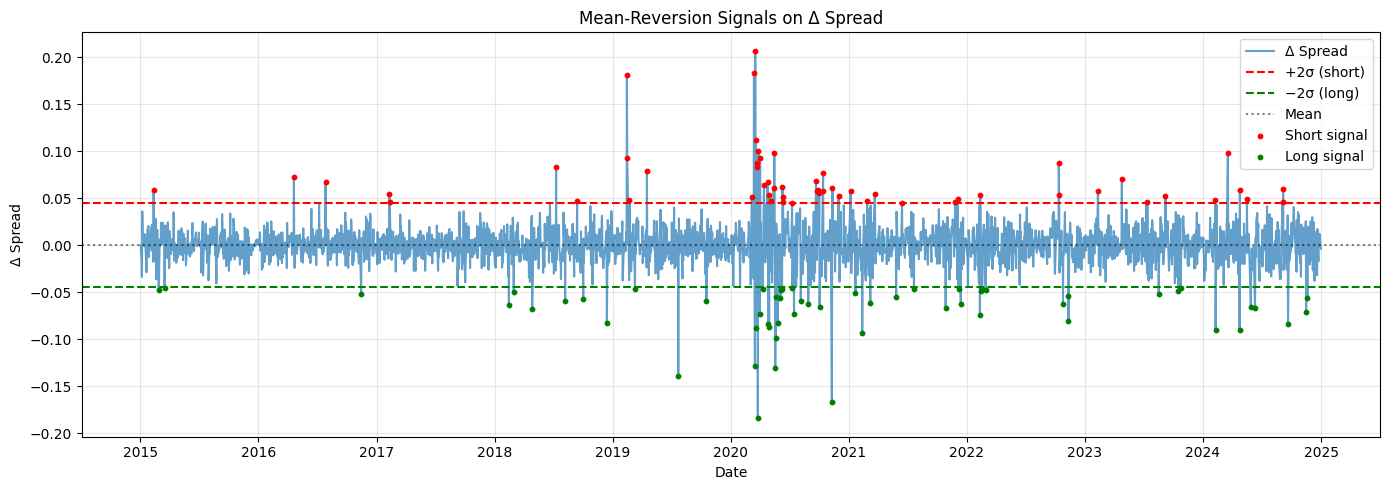

In [17]:
delta_spread = spread.diff().fillna(0).values
delta_mean   = delta_spread.mean()
delta_std    = delta_spread.std()

upper_delta = delta_mean + 2 * delta_std
lower_delta = delta_mean - 2 * delta_std

short_signals_idx = [i for i, v in enumerate(delta_spread) if v > upper_delta]
long_signals_idx  = [i for i, v in enumerate(delta_spread) if v < lower_delta]

short_signals_df = df.iloc[short_signals_idx]
long_signals_df  = df.iloc[long_signals_idx]

print(f"Short-signal dates: {len(short_signals_df)}")
print(f"Long-signal  dates: {len(long_signals_df)}")

plt.figure(figsize=(14, 5))
plt.plot(df.index, delta_spread, label='Δ Spread', alpha=0.7)
plt.axhline(upper_delta, color='red',   linestyle='--', label='+2σ (short)')
plt.axhline(lower_delta, color='green', linestyle='--', label='−2σ (long)')
plt.axhline(delta_mean,  color='black', linestyle=':', alpha=0.5, label='Mean')
plt.scatter(short_signals_df.index,
            delta_spread[short_signals_idx], color='red',   zorder=5, s=10, label='Short signal')
plt.scatter(long_signals_df.index,
            delta_spread[long_signals_idx],  color='green', zorder=5, s=10, label='Long signal')
plt.title('Mean-Reversion Signals on Δ Spread')
plt.xlabel('Date')
plt.ylabel('Δ Spread')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Backtest

Simple 1-day holding-period backtest on **short signals** (buy KO, short PEP).

Total Return   : $-18.60
Max Capital Out: $138.26
Simple Return  : -13.45%


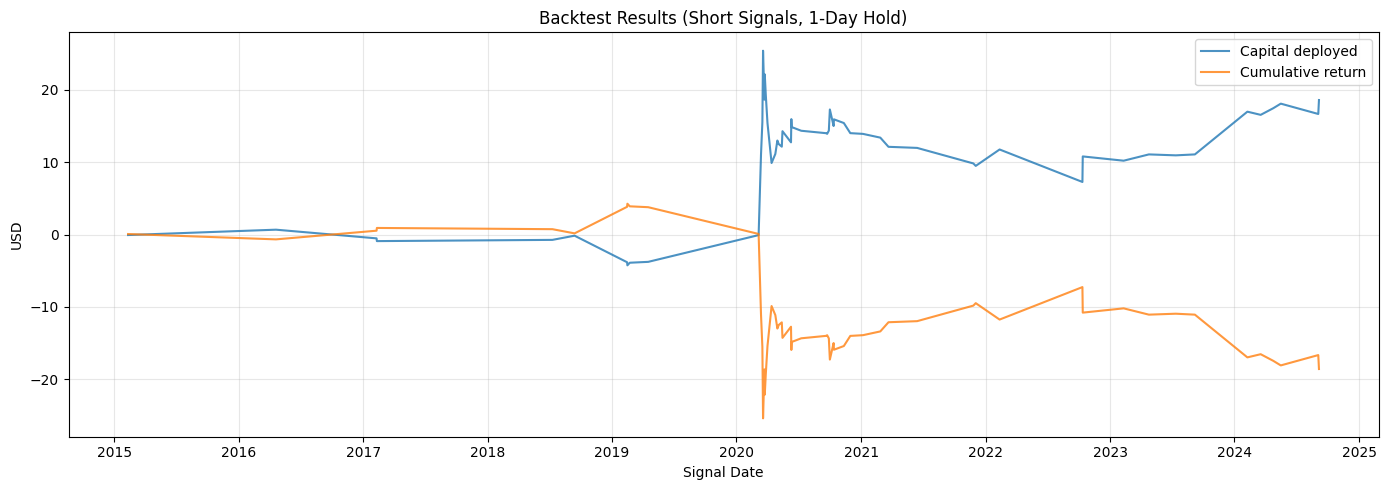

In [18]:
HOLDING_PERIOD = 1

total_return  = 0.0
capital_spent = 0.0
max_capital   = 0.0
equity_curve  = []
capital_curve = []

for i in range(len(short_signals_df)):
    entry_row  = short_signals_df.iloc[i]
    entry_date = short_signals_df.index[i]

    long_price  = entry_row['PEP']
    short_price = entry_row['KO']
    capital_spent += long_price - short_price
    max_capital    = max(max_capital, capital_spent)


    exit_date = entry_date + timedelta(days=HOLDING_PERIOD)
    while exit_date not in df.index:
        exit_date += timedelta(days=1)

    exit_row = df.loc[exit_date]

    pnl_long  = exit_row['PEP'] - long_price
    pnl_short = short_price    - exit_row['KO']
    trade_pnl = pnl_long + pnl_short

    capital_spent -= (exit_row['PEP'] - exit_row['KO'])
    max_capital    = max(max_capital, capital_spent)

    total_return += trade_pnl
    equity_curve.append(total_return)
    capital_curve.append(capital_spent)

print(f"Total Return   : ${total_return:.2f}")
print(f"Max Capital Out: ${max_capital:.2f}")
if max_capital != 0:
    print(f"Simple Return  : {(total_return / max_capital) * 100:.2f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(short_signals_df.index, capital_curve, label='Capital deployed', alpha=0.8)
ax.plot(short_signals_df.index, equity_curve,  label='Cumulative return', alpha=0.8)
ax.set_title('Backtest Results (Short Signals, 1-Day Hold)')
ax.set_xlabel('Signal Date')
ax.set_ylabel('USD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()